# Capped Alanine (coreBetaMap2) — Trajectory Analysis

Analyses the CG simulation trajectory in `example/capped_ala/simulation/trajectory.pkl`
against the reference MD data.  
**CG map**: `coreBetaMap2` — 6 beads, fractional periodic coordinates.  
Bead layout: ACE(0) – N(1) – CA(2) – CB(3?) – C(4) – NME(5)  
(indices follow the `coreBetaMap2` definition in `molecules.py`).

In [1]:
# Set jax no GPU flag to avoid memory issues on GPU
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"

import pickle, json
import numpy as np
import jax.numpy as jnp
from jax_md import space
from matplotlib import pyplot as plt

# project imports
from cgbench.utils.geometry import init_dihedral_fn, compute_atom_distance
from cgbench.utils.chains import compute_line_locations
from cgbench.plotting.timeseries import plot_energy_and_kT, plot_dist_series, plot_dihedrals
from cgbench.plotting.structural import plot_ramachandran
from cgbench.plotting.distributions import plot_1d_bond, plot_1d_dihedral
from chemtrain import quantity

%matplotlib inline

## 1. Load simulation config, trajectory and reference data

In [2]:
EXAMPLE_DIR   = os.path.join(os.path.dirname(os.getcwd()), 'src', 'CG-Mapping-Benchmark', 'example')
SIM_DIR       = os.path.join(EXAMPLE_DIR, 'capped_ala', 'simulation')
DATASET_PATH  = '/ds/project/franz/Datasets/Capped_L-Ala/capped_ala_cg_coreBetaMap2.npz'

# If notebook is run from the example directory itself:
if not os.path.isdir(SIM_DIR):
    SIM_DIR = os.path.join(os.getcwd(), 'capped_ala', 'simulation')

# Simulation config
with open(os.path.join(SIM_DIR, 'traj_config.json')) as f:
    traj_config = json.load(f)
print('traj_config:', traj_config)

traj_config: {'gamma': 100.0, 'print_every': 0.5, 'sim_mode': 'sampling', 'ensemble': 'NVT', 't_total': 1000.0, 'n_chains': 10, 'T': 300.0, 'PRNGKey_seed': 22, 'sim_mol': 'capped_ala', 'type': 'CG', 'cg_map': 'coreBetaMap2', 't_eq': 0.0, 'kT': 2.49435321, 'nmol': 1, 'dt': 0.002, 'box': 3.279370069503784, 'box_volume': 35.2672233581543}


In [3]:
# Trajectory (fractional coordinates, shape: n_frames x n_beads x 3)
with open(os.path.join(SIM_DIR, 'trajectory.pkl'), 'rb') as f:
    traj_coords = jnp.array(pickle.load(f))

# Auxiliary data: epot, etot, force, kT
with open(os.path.join(SIM_DIR, 'traj_state_aux.pkl'), 'rb') as f:
    aux = pickle.load(f)

print('traj_coords shape:', traj_coords.shape,
      '  range:', float(traj_coords.min()), '-', float(traj_coords.max()))
print('aux keys:', list(aux.keys()))

traj_coords shape: (20000, 6, 3)   range: 2.6605557650327682e-06 - 0.9999939799308777
aux keys: ['epot', 'etot', 'force', 'kT']


In [4]:
# Reference CG data (real-space coordinates in nm, shape: n_ref x 6 x 3)
ref_data = np.load(DATASET_PATH)
# Combine training + validation splits
ref_coords_real = np.concatenate([
    ref_data['training__R'],
    ref_data['validation__R'],
], axis=0)

# Box length (nm) – diagonal cubic box
box_len = float(traj_config['box'])          # 3.279370 nm
box     = ref_data['training__box'][0]        # 3×3 matrix

# Convert reference to fractional coordinates (same frame as the trajectory)
ref_coords = ref_coords_real / box_len

print('ref_coords shape:', ref_coords.shape,
      '  range:', ref_coords.min().round(4), '-', ref_coords.max().round(4))
print('box:\n', box)

ref_coords shape: (500000, 6, 3)   range: 0.0 - 0.9999
box:
 [[3.27937 0.      0.     ]
 [0.      3.27937 0.     ]
 [0.      0.      3.27937]]


## 2. Displacement function and chain-boundary locations

In [5]:
# Periodic displacement under fractional PBC
disp_fn, shift_fn = space.periodic_general(box=box, fractional_coordinates=True)

# Chain boundaries: 10 chains × 2000 frames each
line_locs = compute_line_locations(traj_config)
print('Chain boundary frames:', line_locs)

Chain boundary frames: [ 2000  4000  6000  8000 10000 12000 14000 16000 18000]


## 3. Energy and kT time series

In [6]:
outpath = os.path.join(SIM_DIR, 'plots')
os.makedirs(outpath, exist_ok=True)

plot_energy_and_kT(aux, line_locs, outpath)
print('Plots saved to', outpath)

Plots saved to /ds/project/franz/src/CG-Mapping-Benchmark/example/capped_ala/simulation/plots


## 4. Bond lengths

For `coreBetaMap2` the three backbone bonds are:  
`(0,1)  (1,2)  (2,4)` (bead indices)

In [7]:
# coreBetaMap2 bond pairs
pairs = [(0, 1), (1, 2), (2, 4)]

# Compute per-frame distances for reference (subsample to 20 000 frames)
ref_sub = ref_coords[::max(1, len(ref_coords)//20_000)]

ref_dists  = [np.asarray(compute_atom_distance(ref_sub,       i, j, disp_fn)) for i, j in pairs]
traj_dists = [np.asarray(compute_atom_distance(traj_coords,   i, j, disp_fn)) for i, j in pairs]

for (i, j), rd, td in zip(pairs, ref_dists, traj_dists):
    print(f'Bond ({i},{j}):  ref mean={rd.mean():.4f} nm  traj mean={td.mean():.4f} nm')

Bond (0,1):  ref mean=0.1332 nm  traj mean=0.1333 nm
Bond (1,2):  ref mean=0.1467 nm  traj mean=0.1468 nm
Bond (2,4):  ref mean=0.1546 nm  traj mean=0.1545 nm


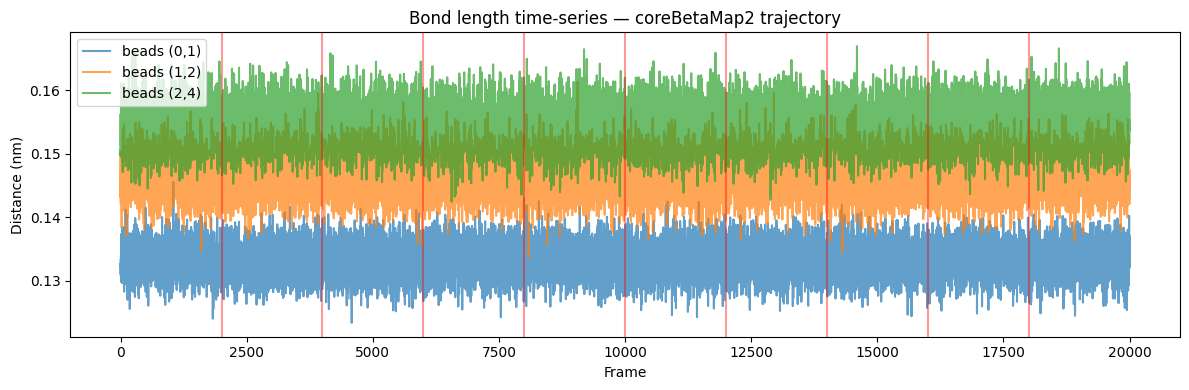

In [8]:
# Bond length time-series (trajectory only)
fig, ax = plt.subplots(figsize=(12, 4))
for (i, j), td in zip(pairs, traj_dists):
    ax.plot(td, alpha=0.7, label=f'beads ({i},{j})')
for loc in line_locs:
    ax.axvline(x=loc, color='r', linestyle='-', alpha=0.4)
ax.set_xlabel('Frame')
ax.set_ylabel('Distance (nm)')
ax.set_title('Bond length time-series — coreBetaMap2 trajectory')
ax.legend()
plt.tight_layout()
plt.show()

Processing bond data for 'Reference': (20000,)
Processing bond data for 'Simulation': (20000,)
Processing bond data for 'Reference': (20000,)
Processing bond data for 'Simulation': (20000,)
Processing bond data for 'Reference': (20000,)
Processing bond data for 'Simulation': (20000,)


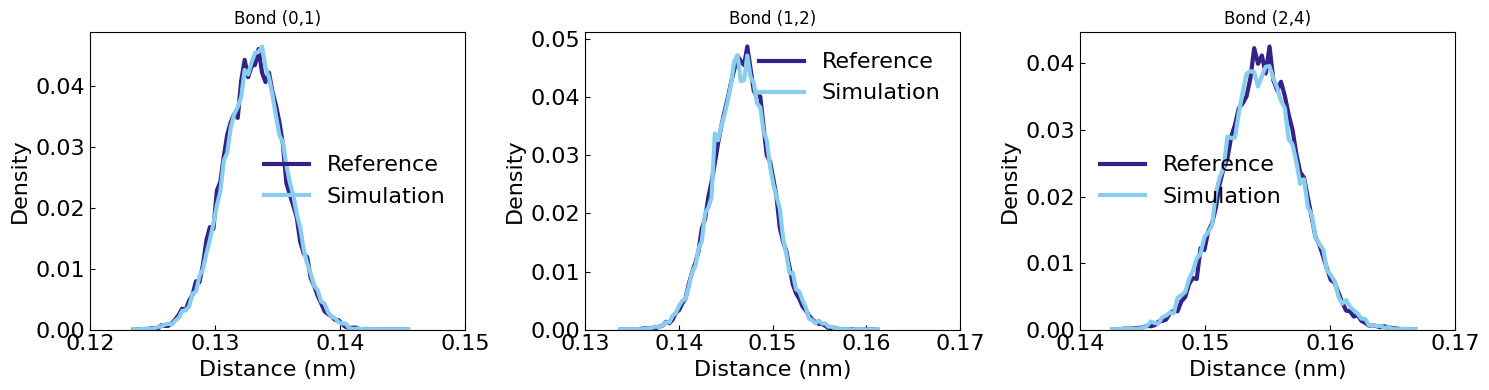

In [9]:
# Bond length distributions: reference vs simulation
fig, axes = plt.subplots(1, len(pairs), figsize=(5 * len(pairs), 4))
for ax, (i, j), rd, td in zip(axes, pairs, ref_dists, traj_dists):
    rd_fin = rd[np.isfinite(rd)]
    td_fin = td[np.isfinite(td)]
    plot_1d_bond(
        ax,
        [rd_fin, td_fin],
        ['Reference', 'Simulation'],
        bins=80,
        xlabel='Distance (nm)',
        mode='single',
    )
    ax.set_title(f'Bond ({i},{j})')
plt.tight_layout()
plt.show()

In [10]:
# Also call the high-level helper to save reference/simulation pair-distance plots to disk
plot_dist_series(pairs, ref_dists, traj_dists, outpath, name='Simulation', line_locations=line_locs)

Plotting atom pair distance series..


## 5. Dihedral angles (φ / ψ)

For `coreBetaMap2`:  
- φ: beads `[0, 1, 2, 4]`  
- ψ: beads `[1, 2, 4, 5]`

In [11]:
phi_indices = [0, 1, 2, 4]
psi_indices = [1, 2, 4, 5]

ala2_dihedral_fn = init_dihedral_fn(disp_fn, [phi_indices, psi_indices])

# Reference phi/psi (subsampled)
AT_phi, AT_psi = ala2_dihedral_fn(ref_sub)
AT_phi, AT_psi = np.asarray(AT_phi), np.asarray(AT_psi)

# Trajectory phi/psi
Traj_phi, Traj_psi = ala2_dihedral_fn(traj_coords)
Traj_phi, Traj_psi = np.asarray(Traj_phi), np.asarray(Traj_psi)

print('phi  — ref mean:', AT_phi.mean().round(2), ' traj mean:', Traj_phi.mean().round(2))
print('psi  — ref mean:', AT_psi.mean().round(2), ' traj mean:', Traj_psi.mean().round(2))

phi  — ref mean: -97.5  traj mean: -96.04
psi  — ref mean: 92.06  traj mean: 41.0


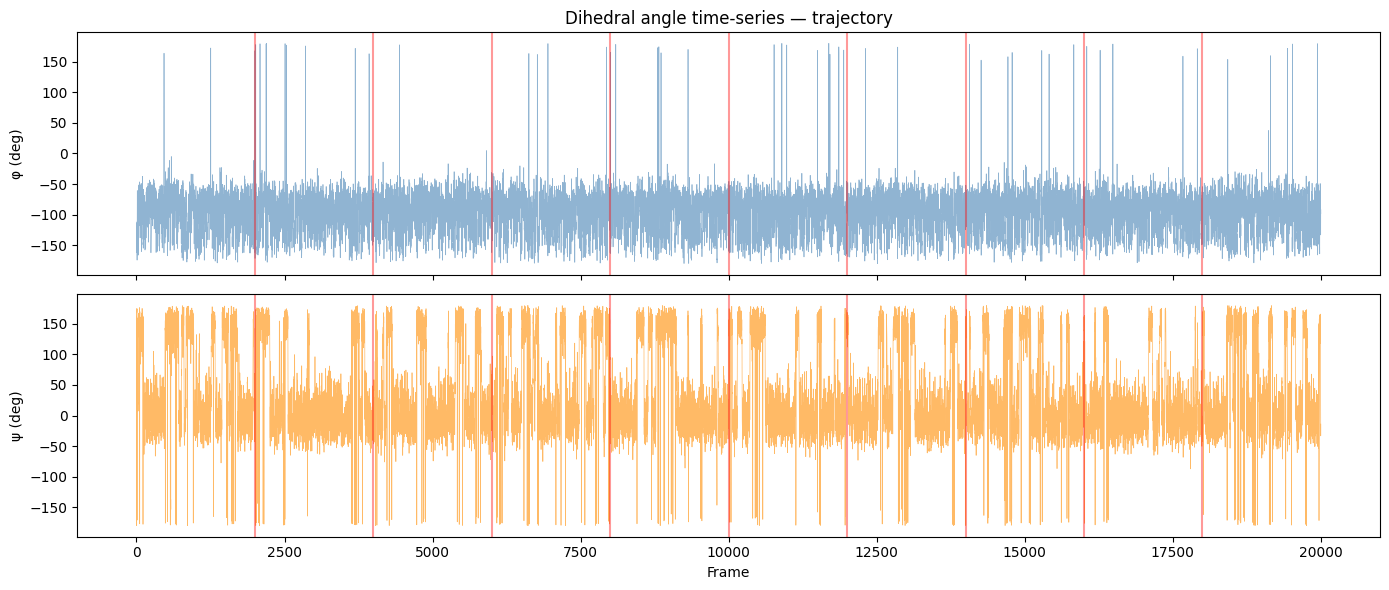

In [12]:
# Dihedral time-series
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(Traj_phi, color='steelblue', alpha=0.6, linewidth=0.5)
for loc in line_locs:
    ax1.axvline(x=loc, color='r', linestyle='-', alpha=0.4)
ax1.set_ylabel('φ (deg)')
ax1.set_title('Dihedral angle time-series — trajectory')

ax2.plot(Traj_psi, color='darkorange', alpha=0.6, linewidth=0.5)
for loc in line_locs:
    ax2.axvline(x=loc, color='r', linestyle='-', alpha=0.4)
ax2.set_ylabel('ψ (deg)')
ax2.set_xlabel('Frame')

plt.tight_layout()
plt.show()

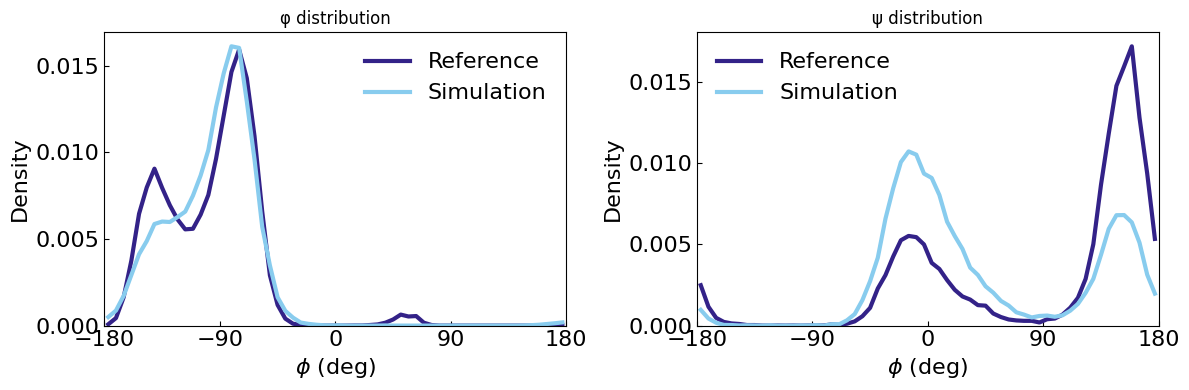

In [13]:
# 1D dihedral distributions: reference vs simulation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

plot_1d_dihedral(ax1, [AT_phi, Traj_phi], ['Reference', 'Simulation'], bins=60, degrees=True)
ax1.set_title('φ distribution')

plot_1d_dihedral(ax2, [AT_psi, Traj_psi], ['Reference', 'Simulation'], bins=60, degrees=True)
ax2.set_title('ψ distribution')

plt.tight_layout()
plt.show()

In [14]:
# Save dihedral plots to disk via the high-level helper
plot_dihedrals(AT_phi, AT_psi, Traj_phi, Traj_psi, outpath, line_locs)

Plotting dihedrals..


## 6. Ramachandran plot (free-energy surface)

In [15]:
kT = 300.0 * quantity.kb   # kJ/mol at 300 K
plot_ramachandran(AT_phi, AT_psi, Traj_phi, Traj_psi, kT, outpath)
print('Ramachandran plot saved to', outpath)

Ramachandran plot saved to /ds/project/franz/src/CG-Mapping-Benchmark/example/capped_ala/simulation/plots


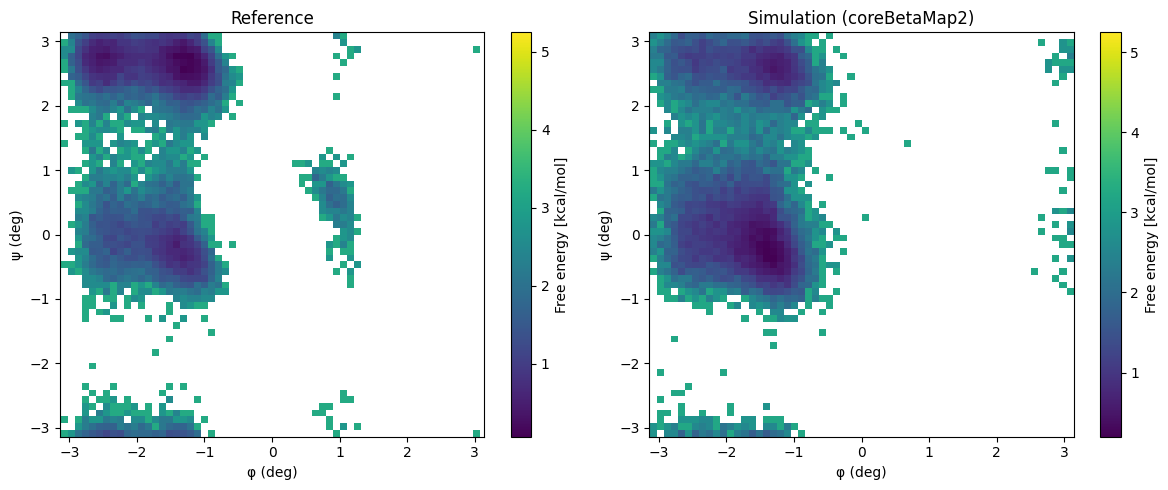

: 

In [ ]:
# Inline Ramachandran for quick inspection
from cgbench.plotting.structural import plot_histogram_free_energy_simple

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1, c1 = plot_histogram_free_energy_simple(ax1, AT_phi, AT_psi, kT)
ax1.set_title('Reference')
ax1.set_xlabel('φ (deg)')
ax1.set_ylabel('ψ (deg)')
plt.colorbar(c1, ax=ax1, label='Free energy [kcal/mol]')

ax2, c2 = plot_histogram_free_energy_simple(ax2, Traj_phi, Traj_psi, kT)
ax2.set_title('Simulation (coreBetaMap2)')
ax2.set_xlabel('φ (deg)')
ax2.set_ylabel('ψ (deg)')
plt.colorbar(c2, ax=ax2, label='Free energy [kcal/mol]')

plt.tight_layout()
plt.show()